# 1. Imports

In [7]:
# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt

# Pipeline y preprocesado
from sklearn.base import BaseEstimator, TransformerMixin  # para transformers personalizados
from sklearn.pipeline import Pipeline                      # para encadenar pasos
from sklearn.compose import ColumnTransformer             # para aplicar transformaciones por columnas
from sklearn.model_selection import train_test_split      # para dividir los datos
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

# Modelos
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

# Métricas
from sklearn.metrics import (
    precision_score,
    recall_score,
    average_precision_score,  # PR-AUC
    ConfusionMatrixDisplay,
    precision_recall_curve,
    fbeta_score,
    f1_score
)

import shap
import time

import joblib
import os

# Gráficos
import matplotlib.pyplot as plt

# 2. Carga

In [8]:
data_path = '../data/diabetes_prediction_dataset.csv'
data = pd.read_csv(data_path)

print('filas antes de filtrar:', data.shape[0])

filas antes de filtrar: 100000


# 3. Filtrado de valores no plausibles y categorías irrelevantes

In [9]:
data = data[data['bmi'] < 65]
data = data[data['gender'] != 'Other']

print('Filas después de filtrar:', data.shape[0])

data.head()

Filas después de filtrar: 99935


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


# 3. Se definen los predictores y el target

In [10]:
X = data.drop(columns=['diabetes'])
y = data['diabetes']

In [11]:
data['smoking_history'].value_counts()

smoking_history
No Info        35800
never          35071
former          9346
current         9278
not current     6438
ever            4002
Name: count, dtype: int64

# 4. Split train/test

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=42,
                                                    stratify=y)

# 5. Transformers personalizados y encodings

In [13]:
class SmokingMerger(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        X['smoking_history'] = X['smoking_history'].astype(str).map({
            'No Info':     'Unknown',
            'never':       'Never',
            'former':      'Former',
            'current':     'Current',
            'not current': 'Former',
            'ever':        'Former'
        })
        return X

In [14]:
preprocessor = ColumnTransformer([
    ('categorical', OneHotEncoder(handle_unknown='ignore'), ['gender', 'smoking_history']),
], remainder='passthrough', verbose_feature_names_out=False)

# 6. Pipeline

In [15]:
pipeline = Pipeline([
    ('smoking_merger', SmokingMerger()),
    ('preprocessor', preprocessor)
])

Se comprueba que funciona correctamente:

In [16]:
pipeline.fit(X_train, y_train)

X_train_transformed = pipeline.named_steps['preprocessor'].transform(
    pipeline.named_steps['smoking_merger'].transform(X_train)
)

feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()

pd.DataFrame(X_train_transformed, columns=feature_names).head()

,gender_Female,gender_Male,smoking_history_Current,smoking_history_Former,smoking_history_Never,smoking_history_Unknown,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level
0,0.0,1.0,1.0,0.0,0.0,0.0,43.0,0.0,0.0,21.06,5.7,126.0
1,1.0,0.0,0.0,0.0,0.0,1.0,2.0,0.0,0.0,15.72,4.8,126.0
2,1.0,0.0,0.0,0.0,1.0,0.0,48.0,1.0,0.0,27.32,6.0,155.0
3,0.0,1.0,0.0,0.0,1.0,0.0,20.0,0.0,0.0,24.60,6.2,200.0
4,1.0,0.0,0.0,0.0,1.0,0.0,29.0,0.0,0.0,27.17,6.5,200.0


# 7. Random Forest - Baseline

Los hiperparámetros fijos del modelo de referencia son:

- **n_estimators=100**: número de árboles que componen el bosque. Cada árbol se entrena sobre una muestra aleatoria de datos y features; la predicción final es el promedio de las predicciones de todos ellos. 100 es el valor de referencia estándar.
- **max_depth=None**: profundidad máxima de cada árbol, es decir, el número máximo de divisiones desde la raíz hasta una hoja. Con `None` los árboles crecen sin restricción hasta que todas las hojas son puras, lo que favorece la memorización del conjunto de entrenamiento (overfitting).
- **class_weight='balanced'**: ajusta automáticamente el peso de cada clase de forma inversamente proporcional a su frecuencia. Penaliza más los errores en la clase minoritaria (diabéticos, ~8.5%) para que el modelo no ignore estos casos al optimizar.
- **random_state=42**: semilla del generador de números aleatorios que garantiza la reproducibilidad del experimento.

Se define el pipeline con hiperparámetros fijos:

In [17]:
rf_baseline = Pipeline([
    ('smoking_merger', SmokingMerger()),
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=100,
        max_depth=None,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

Entrenamiento:

In [18]:
rf_baseline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('smoking_merger', ...), ('preprocessor', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different 

Evaluación final train/test:

=== TRAIN ===
Recall:    0.9988
Precision: 0.9882
PR-AUC:    0.9994

=== TEST ===
Recall:    0.6889
Precision: 0.9219
PR-AUC:    0.8587


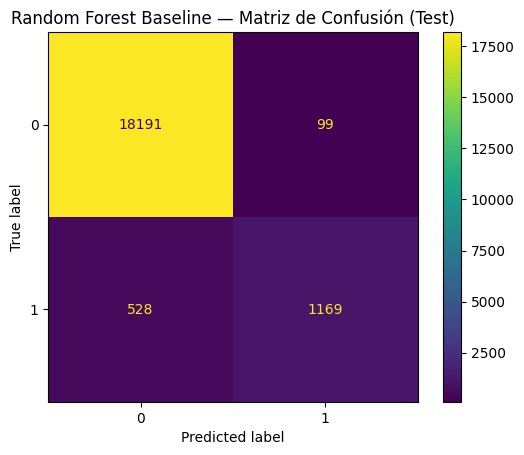

In [19]:
y_pred_train_base = rf_baseline.predict(X_train)
y_prob_train_base = rf_baseline.predict_proba(X_train)[:, 1]

y_pred_test_base = rf_baseline.predict(X_test)
y_prob_test_base = rf_baseline.predict_proba(X_test)[:, 1]

print("=== TRAIN ===")
print(f"Recall:    {recall_score(y_train, y_pred_train_base):.4f}")
print(f"Precision: {precision_score(y_train, y_pred_train_base):.4f}")
print(f"PR-AUC:    {average_precision_score(y_train, y_prob_train_base):.4f}")

print("\n=== TEST ===")
print(f"Recall:    {recall_score(y_test, y_pred_test_base):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_test_base):.4f}")
print(f"PR-AUC:    {average_precision_score(y_test, y_prob_test_base):.4f}")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test_base)
plt.title('Random Forest Baseline — Matriz de Confusión (Test)')
plt.show()

**Análisis del baseline:**

El baseline presenta un **overfitting severo**: en train, PR-AUC = 0.9994 y Recall = 0.9988, mientras que en test caen a 0.8587 y 0.6889 respectivamente. La ausencia de restricciones de profundidad (`max_depth=None`) permite que cada árbol memorice el conjunto de entrenamiento.

En test, el modelo es muy **conservador**: solo predice diabetes cuando la mayoría de los árboles está muy segura, lo que resulta en una Precision alta (0.9219) pero un Recall bajo (0.6889). En la matriz de confusión, **528 pacientes diabéticos no son detectados** (Falsos Negativos) frente a únicamente 99 alarmas falsas (Falsos Positivos).

En el contexto de **detección temprana de diabetes**, un Recall del 68.9% es clínicamente insuficiente: más de 1 de cada 3 pacientes diabéticos pasa desapercibido, perdiendo la oportunidad de intervención temprana y aumentando el riesgo de complicaciones. La alta Precision, aunque positiva, no compensa este riesgo.

# 8. Random Forest Baseline - Optimización del umbral de clasificación

El baseline obtuvo un Recall bajo (0.6889) con el umbral por defecto (0.5). Se busca ahora el umbral óptimo sobre las probabilidades ya calculadas en §7, maximizando el F2-score para priorizar el Recall sobre la Precision. El objetivo es cuantificar cuánto puede mejorar el Recall del baseline únicamente ajustando el punto de corte, sin reentrenar ni modificar el modelo.

In [20]:
thresholds = np.arange(0.1, 0.9, 0.01)

# Buscar umbral óptimo sobre TRAIN
f2_scores_train_base = []
for threshold in thresholds:
    y_pred_t = (y_prob_train_base >= threshold).astype(int)
    f2_scores_train_base.append(fbeta_score(y_train, y_pred_t, beta=2, zero_division=0))

best_threshold_base = thresholds[np.argmax(f2_scores_train_base)]
print(f'Umbral óptimo (optimizado en train): {best_threshold_base:.2f}')
print(f'F2 máximo en train: {max(f2_scores_train_base):.4f}')


Umbral óptimo (optimizado en train): 0.42
F2 máximo en train: 0.9971



=== TEST CON UMBRAL ÓPTIMO ===
Recall:    0.7130
Precision: 0.8718
PR-AUC:    0.8587


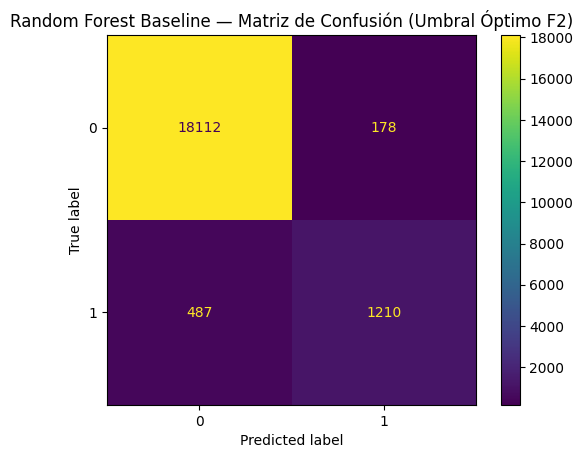

In [21]:

# Aplicar umbral óptimo sobre TEST
y_pred_optimal_base = (y_prob_test_base >= best_threshold_base).astype(int)

print("\n=== TEST CON UMBRAL ÓPTIMO ===")
print(f"Recall:    {recall_score(y_test, y_pred_optimal_base):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_optimal_base):.4f}")
print(f"PR-AUC:    {average_precision_score(y_test, y_prob_test_base):.4f}")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_optimal_base)
plt.title('Random Forest Baseline — Matriz de Confusión (Umbral Óptimo F2)')
plt.show()

**Análisis del baseline con umbral optimizado:**

El umbral óptimo encontrado en train es **0.42**, por debajo del 0.5 por defecto, lo que hace al modelo más propenso a predecir diabetes. El resultado en test es una mejora modesta: el Recall sube de 0.6889 a **0.7130** (+2.4 pp) y los Falsos Negativos se reducen de 528 a **487** (−41 pacientes no detectados), a costa de aumentar los Falsos Positivos de 99 a 178.

El F2 en train de **0.9971** refleja el mismo overfitting visto en §7: el modelo memoriza el conjunto de entrenamiento casi perfectamente, pero esa capacidad no se transfiere al test. Ajustar el umbral no corrige el problema de fondo — la falta de regularización — y por eso la ganancia en Recall es tan pequeña.

En conclusión, la optimización del umbral sobre un modelo mal regularizado tien

# 9. Random Forest con optimización de hiperparámetros

Se definen los hiperparámetros:

In [22]:


rf_params = {
    'model__n_estimators': [100, 200, 300, 500],
    'model__max_depth': [5, 10, 15, 20, None],
    'model__max_features': ['sqrt', 'log2'],
    'model__min_samples_split': [2, 10, 15, 20],
    'model__min_samples_leaf': [ 5, 10, 15, 20],
    'model__max_samples': [None, 0.7, 0.8],
    'model__ccp_alpha': [0.0, 0.001, 0.01]
}

Se aplica el pipeline: 

Los hiperparámetros explorados por el RandomizedSearchCV y su significado son:

- **n_estimators** [100, 200, 300, 500]: número de árboles del bosque. Más árboles reducen la varianza del modelo (efecto del promediado) a costa de mayor tiempo de cómputo.
- **max_depth** [5, 10, 15, 20, None]: profundidad máxima de cada árbol. Limitar la profundidad impide que los árboles memoricen el conjunto de entrenamiento; `None` significa sin restricción.
- **max_features** ['sqrt', 'log2']: número de features evaluadas en cada split. Reducir este número aumenta la diversidad entre árboles y reduce la correlación del ensemble.
- **min_samples_split** [2, 10, 15, 20]: número mínimo de muestras necesarias para dividir un nodo. Valores altos evitan divisiones sobre grupos con escasa información estadística, reduciendo el sobreajuste.
- **min_samples_leaf** [5, 10, 15, 20]: número mínimo de muestras que debe contener una hoja. Impide hojas muy pequeñas que memoricen casos concretos; es el principal mecanismo de regularización a nivel de nodo.
- **max_samples** [None, 0.7, 0.8]: fracción del conjunto de entrenamiento usada para entrenar cada árbol (bagging). `None` equivale al 100%; valores menores aumentan la diversidad del ensemble.
- **ccp_alpha** [0.0, 0.001, 0.01]: parámetro de poda de coste-complejidad post-entrenamiento. Valores mayores podan más ramas, simplificando el modelo.

In [23]:

rf_pipeline = Pipeline([
    ('smoking_merger', SmokingMerger()),
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        bootstrap=True,
        n_jobs=-1,
        random_state=42,
        class_weight='balanced',
        criterion='gini'
    ))
])


Se configura el RandomizedSearchCV:

In [24]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_search = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=rf_params,
    n_iter=30,
    scoring='average_precision',
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

Entrenamiento: 

In [25]:
rf_search.fit(X_train, y_train)
print('Mejores parámetros:', rf_search.best_params_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


c:\Users\dmoya\grupo_1\.venv\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Mejores parámetros: {'model__n_estimators': 300, 'model__min_samples_split': 15, 'model__min_samples_leaf': 20, 'model__max_samples': 0.7, 'model__max_features': 'log2', 'model__max_depth': 15, 'model__ccp_alpha': 0.0}


Los mejores hiperparámetros encontrados son:

- **n_estimators=300**: mayor número de árboles que el baseline (100), ofreciendo mayor estabilidad y reducción de varianza.
- **max_depth=15**: profundidad limitada, principal corrección frente al overfitting del baseline (`max_depth=None`).
- **max_features='log2'**: subconjunto mínimo de features por split, maximizando la diversidad entre árboles del ensemble.
- **min_samples_split=15** y **min_samples_leaf=20**: valores altos de regularización que evitan divisiones y hojas con pocos datos, forzando al modelo a aprender patrones más generales.
- **max_samples=0.7**: bagging con el 70% de las muestras por árbol, añadiendo diversidad adicional al ensemble.
- **ccp_alpha=0.0**: la regularización ya está cubierta por los parámetros anteriores; la poda explícita no aporta mejora adicional.

En conjunto, los parámetros elegidos apuntan hacia un modelo fuertemente regularizado: árboles de profundidad moderada con restricciones en nodos y hojas, y diversidad forzada tanto en muestras como en features. Esto confirma que el principal problema del baseline era el overfitting por exceso de complejidad.

Resultados por fold. Muestra las 3 mejores combinaciones de hiperparámetros ordenadas por PR-AUC medio descendente:

In [26]:
results = pd.DataFrame(rf_search.cv_results_)
results[[
    'param_model__n_estimators',
    'param_model__max_depth',
    'param_model__max_features',
    'param_model__min_samples_split',
    'param_model__min_samples_leaf',
    'param_model__max_samples',
    'param_model__ccp_alpha',
    'mean_test_score',
    'std_test_score',
    'rank_test_score'
]].sort_values('mean_test_score', ascending=False).head(3)

,param_model__n_estimators,param_model__max_depth,param_model__max_features,param_model__min_samples_split,param_model__min_samples_leaf,param_model__max_samples,param_model__ccp_alpha,mean_test_score,std_test_score,rank_test_score
29,300,15,log2,15,20,0.7,0.0,0.880030,0.005381,1
22,100,20,sqrt,2,15,None,0.0,0.879919,0.005413,2
15,200,None,sqrt,10,10,0.8,0.0,0.879782,0.005661,3


Evaluacion final train/test:

=== TRAIN ===
Recall:    0.9237
Precision: 0.5238
PR-AUC:    0.9044

=== TEST ===
Recall:    0.9034
Precision: 0.5207
PR-AUC:    0.8833


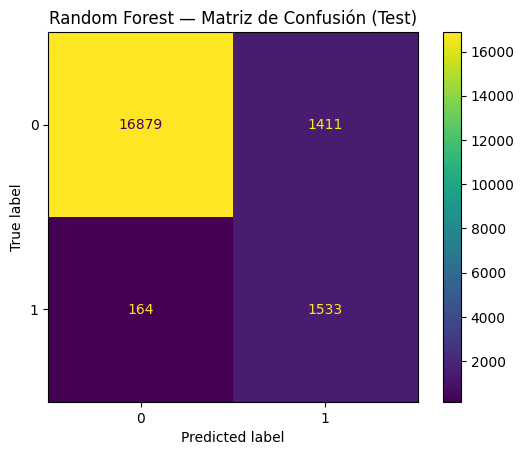

In [27]:
# Train
y_pred_train = rf_search.predict(X_train)
y_prob_train = rf_search.predict_proba(X_train)[:, 1]

# Test
y_pred_test = rf_search.predict(X_test)
y_prob_test = rf_search.predict_proba(X_test)[:, 1]

print("=== TRAIN ===")
print(f"Recall:    {recall_score(y_train, y_pred_train):.4f}")
print(f"Precision: {precision_score(y_train, y_pred_train):.4f}")
print(f"PR-AUC:    {average_precision_score(y_train, y_prob_train):.4f}")

print("\n=== TEST ===")
print(f"Recall:    {recall_score(y_test, y_pred_test):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_test):.4f}")
print(f"PR-AUC:    {average_precision_score(y_test, y_prob_test):.4f}")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test)
plt.title('Random Forest — Matriz de Confusión (Test)')
plt.show()

La regularización introduce un cambio radical en el trade-off respecto al baseline: el Recall en test sube de **0.6889 a 0.9034** (+21 pp), mientras la Precision cae de 0.9219 a 0.5207. La brecha train/test se reduce notablemente (Recall 0.9237 en train vs 0.9034 en test), confirmando que los hiperparámetros de regularización (`max_depth=15`, `min_samples_leaf=20`, `max_samples=0.7`) controlan eficazmente el overfitting.

En la matriz de confusión, los Falsos Negativos caen de **528 a 164** (−364 pacientes no detectados), a costa de aumentar los Falsos Positivos de 99 a 1411. En un contexto médico, este intercambio es favorable: identificar correctamente al 90% de los pacientes diabéticos reduce drásticamente el riesgo de complicaciones no tratadas, mientras que un falso positivo únicamente genera una prueba de confirmación adicional.

El PR-AUC mejora de 0.8587 a **0.8833**. La ganancia principal, sin embargo, no está en el área bajo la curva sino en el reposicionamiento del umbral de clasificación, que se optimizará en la sección 10 para maximizar el F2-score y ajustar aún más el balance precisión-recall.

## Feature Importance - Shap Values

In [32]:
best_pipeline = rf_search.best_estimator_
smoking_merger_fit = best_pipeline.named_steps['smoking_merger']
preprocessor_fit   = best_pipeline.named_steps['preprocessor']
best_rf            = best_pipeline.named_steps['model']

Xp_train = preprocessor_fit.transform(smoking_merger_fit.transform(X_train))
fnames   = list(preprocessor_fit.get_feature_names_out())

X_shap = Xp_train[:500]

explainer = shap.TreeExplainer(best_rf)
sv = explainer.shap_values(X_shap)
if isinstance(sv, list):
    shap_class1 = sv[1]
else:
    shap_class1 = sv[:, :, 1]


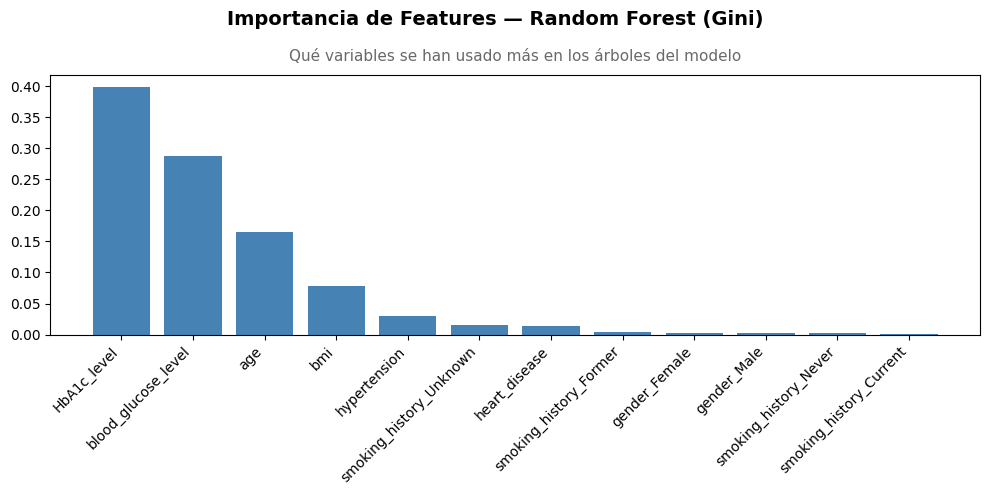

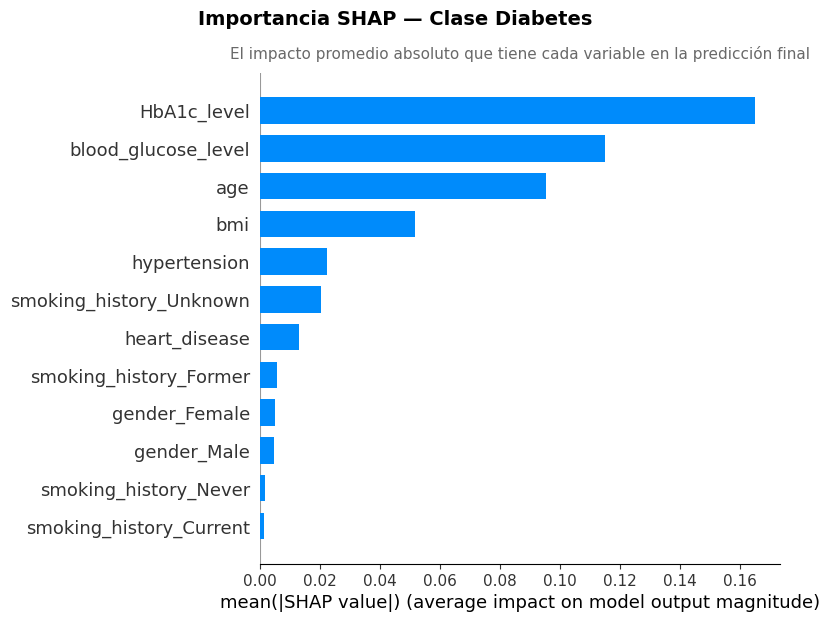

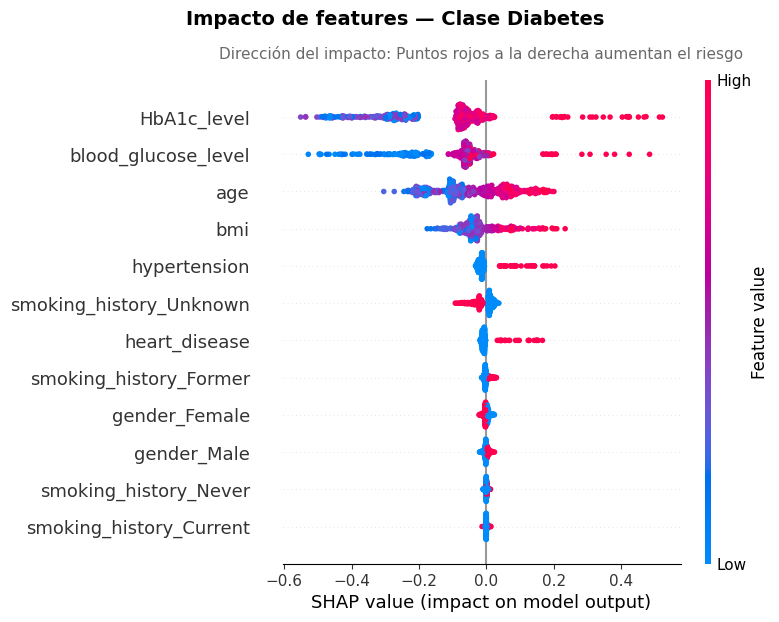

In [33]:
best_rf = rf_search.best_estimator_.named_steps['model']

# --- Feature Importance nativa (Gini) ---
importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(10, 5))
plt.bar(range(len(fnames)), importances[indices], color='steelblue')
plt.xticks(range(len(fnames)), [fnames[i] for i in indices], rotation=45, ha='right')

# TÍTULO Y SUBTÍTULO CORREGIDOS:
plt.suptitle('Importancia de Features — Random Forest (Gini)', fontsize=14, fontweight='bold')
plt.title('Qué variables se han usado más en los árboles del modelo', fontsize=11, color='dimgrey', pad=10)

plt.tight_layout()
plt.show()

# --- SHAP Gráfico de Barras ---
shap.summary_plot(shap_class1, X_shap, feature_names=fnames, plot_type='bar', show=False)

# TÍTULO Y SUBTÍTULO CORREGIDOS:
plt.suptitle('Importancia SHAP — Clase Diabetes', fontsize=14, fontweight='bold')
plt.title('El impacto promedio absoluto que tiene cada variable en la predicción final', fontsize=11, color='dimgrey', pad=10)

plt.tight_layout()
plt.show()

# --- SHAP Gráfico de Puntos (Beeswarm) ---
shap.summary_plot(shap_class1, X_shap, feature_names=fnames, show=False)

# TÍTULO Y SUBTÍTULO CORREGIDOS:
plt.suptitle('Impacto de features — Clase Diabetes', fontsize=14, fontweight='bold')
plt.title('Dirección del impacto: Puntos rojos a la derecha aumentan el riesgo', fontsize=11, color='dimgrey', pad=15)

plt.tight_layout()
plt.show()


# 10. Random Forest con optimización de hiperparámetros y umbral de clasificación

In [34]:
thresholds = np.arange(0.1, 0.9, 0.01)

# Buscar umbral óptimo sobre TRAIN
f2_scores_train = []
for threshold in thresholds:
    y_pred_t = (y_prob_train >= threshold).astype(int)
    f2_scores_train.append(fbeta_score(y_train, y_pred_t, beta=2, zero_division=0))

best_threshold = thresholds[np.argmax(f2_scores_train)]
print(f'Umbral óptimo (optimizado en train): {best_threshold:.2f}')
print(f'F2 máximo en train: {max(f2_scores_train):.4f}')

Umbral óptimo (optimizado en train): 0.60
F2 máximo en train: 0.8166


=== TEST CON UMBRAL ÓPTIMO ===
Umbral F2 (optimizado en train): 0.60
Recall:    0.8415
Precision: 0.6217
PR-AUC:    0.8833


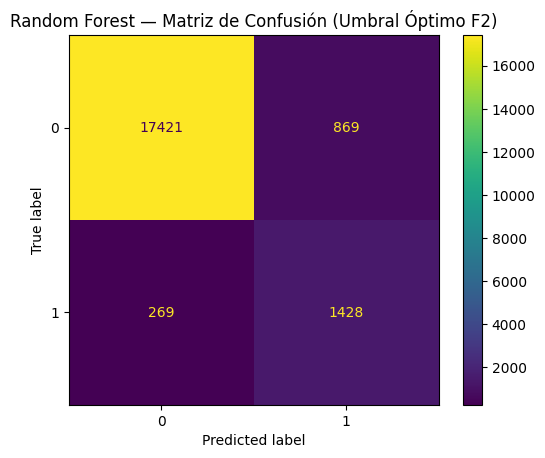

In [35]:
# Aplicar umbral óptimo sobre TEST
y_pred_optimal = (y_prob_test >= best_threshold).astype(int)

print("=== TEST CON UMBRAL ÓPTIMO ===")
print(f"Umbral F2 (optimizado en train): {best_threshold:.2f}")
print(f"Recall:    {recall_score(y_test, y_pred_optimal):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_optimal):.4f}")
print(f"PR-AUC:    {average_precision_score(y_test, y_prob_test):.4f}")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_optimal)
plt.title('Random Forest — Matriz de Confusión (Umbral Óptimo F2)')
plt.show()

El umbral óptimo encontrado en train es 0.60, por encima del 0.5 por defecto, esto sigue una dirección opuesta al apartado 8 (donde bajó a 0.42). Esto ocurre porque el modelo regularizado ya parte de un Recall alto (0.9034) con el umbral por defecto, por lo que el F2 en train mejora siendo algo más exigente en la predicción positiva: sube la Precision sin sacrificar demasiado Recall.

El resultado en test refleja ese intercambio: el Recall baja de 0.9034 a 0.8415 (−6.2 pp) y la Precision sube de 0.5207 a 0.6217 (+10.1 pp). En la matriz de confusión, los Falsos Negativos aumentan de 164 a 269 (+105 pacientes diabéticos no detectados), mientras que los Falsos Positivos se reducen considerablemente de 1411 a 869 (−542 alarmas falsas).

El F2 máximo en train de 0.8166 contrasta con el 0.9971 del apartado 8, lo que indica que el modelo regularizado generaliza de forma mucho más realista. El PR-AUC permanece en 0.8833, como se esperaba al no modificar el modelo.

En un contexto médico, la elección entre un modelo con umbral 0.5 (apartado 9) y un modelo con umbral 0.60 (apartado 10) depende de la prioridad clínica: si minimizar los diagnósticos perdidos es crítico, el umbral 0.5 es preferible (164 FN frente a 269); si se busca reducir el número de pruebas de confirmación innecesarias manteniendo un Recall razonable del 84%, el umbral 0.6 ofrece un trade-off más equilibrado.

# 11. Guardar y cargar los modelos

## 11.1. Guardar:

In [36]:
import joblib

os.makedirs('artifacts_rf', exist_ok=True)

# Modelos
joblib.dump(rf_baseline,               'artifacts_rf/rf_baseline.pkl')
joblib.dump(rf_search.best_estimator_, 'artifacts_rf/rf_optimized.pkl')

# Umbrales óptimos
joblib.dump({
    'best_threshold_base': best_threshold_base,
    'best_threshold':      best_threshold
}, 'artifacts_rf/thresholds.pkl')

# Probabilidades (evita recalcularlas)
np.save('artifacts_rf/y_prob_train_base.npy', y_prob_train_base)
np.save('artifacts_rf/y_prob_test_base.npy',  y_prob_test_base)
np.save('artifacts_rf/y_prob_train.npy',      y_prob_train)
np.save('artifacts_rf/y_prob_test.npy',       y_prob_test)

print('Guardado en artifacts_rf/')


Guardado en artifacts_rf/


# 11.2. Cargar: 

In [37]:
import joblib

rf_baseline   = joblib.load('artifacts_rf/rf_baseline.pkl')
rf_optimized  = joblib.load('artifacts_rf/rf_optimized.pkl')

thresholds         = joblib.load('artifacts_rf/thresholds.pkl')
best_threshold_base = thresholds['best_threshold_base']
best_threshold      = thresholds['best_threshold']

y_prob_train_base = np.load('artifacts_rf/y_prob_train_base.npy')
y_prob_test_base  = np.load('artifacts_rf/y_prob_test_base.npy')
y_prob_train      = np.load('artifacts_rf/y_prob_train.npy')
y_prob_test       = np.load('artifacts_rf/y_prob_test.npy')

print('Cargado desde artifacts_rf/')


Cargado desde artifacts_rf/


# 12. Curva Precision-Recall entre RF baseline y RF optimizado

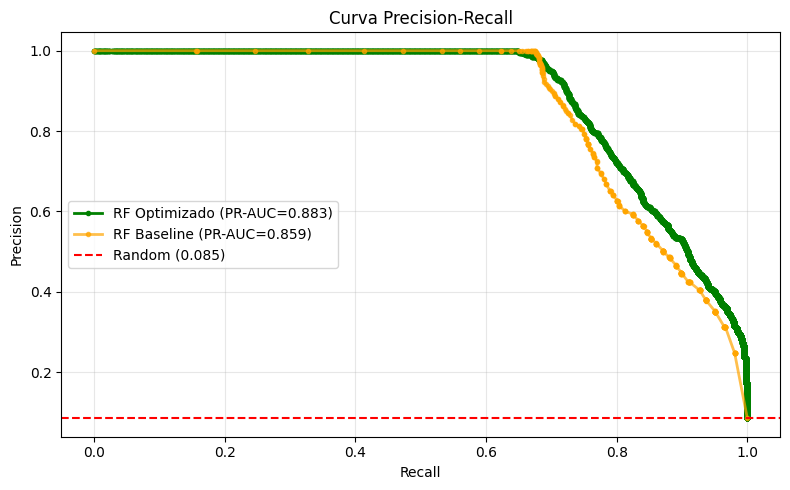

Guardado: artifacts_rf/rf_pr_curve.png


In [39]:
pr_opt,  re_opt,  _ = precision_recall_curve(y_test, y_prob_test)
pr_base, re_base, _ = precision_recall_curve(y_test, y_prob_test_base)

pr_auc_opt  = average_precision_score(y_test, y_prob_test)
pr_auc_base = average_precision_score(y_test, y_prob_test_base)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(re_opt,  pr_opt,  marker='.', label=f'RF Optimizado (PR-AUC={pr_auc_opt:.3f})',  color='green',  lw=2)
ax.plot(re_base, pr_base, marker='.', label=f'RF Baseline (PR-AUC={pr_auc_base:.3f})',   color='orange', lw=2, alpha=0.7)
ax.axhline(y=y_test.mean(), color='red', ls='--', label=f'Random ({y_test.mean():.3f})')
ax.set(xlabel='Recall', ylabel='Precision', title='Curva Precision-Recall')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts_rf/rf_pr_curve.png', dpi=100, bbox_inches='tight')
plt.show()
print('Guardado: artifacts_rf/rf_pr_curve.png')


A partir de un Recall de 0.70, RF Optimizado se posiciona de forma consistente por encima de RF Baseline.

# 13. Threshold Tuning

Threshold óptimo (optimizado en train): 0.60
  Precision: 0.6217
  Recall:    0.8415
  F2:        0.7859
  F1:        0.7151


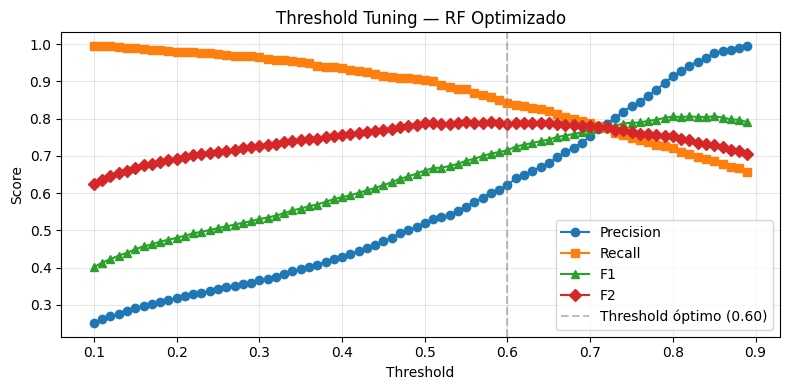


Comparación: default (0.5) vs óptimo (0.60)
  Recall default:    0.9034  ->  óptimo: 0.8415
  Precision default: 0.5207  ->  óptimo: 0.6217


In [41]:
thresholds_plot = np.arange(0.1, 0.9, 0.01)
scores = []
for t in thresholds_plot:
    y_pred_t = (y_prob_test >= t).astype(int)
    scores.append({
        'threshold': t,
        'precision': precision_score(y_test, y_pred_t, zero_division=0),
        'recall':    recall_score(y_test, y_pred_t),
        'f1':        f1_score(y_test, y_pred_t, zero_division=0),
        'f2':        fbeta_score(y_test, y_pred_t, beta=2, zero_division=0)
    })
df_t = pd.DataFrame(scores)

best_row = df_t.iloc[(df_t['threshold'] - best_threshold).abs().argsort()[:1]]
print(f'Threshold óptimo (optimizado en train): {best_threshold:.2f}')
print(f'  Precision: {best_row["precision"].values[0]:.4f}')
print(f'  Recall:    {best_row["recall"].values[0]:.4f}')
print(f'  F2:        {best_row["f2"].values[0]:.4f}')
print(f'  F1:        {best_row["f1"].values[0]:.4f}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(df_t['threshold'], df_t['precision'], label='Precision', marker='o')
ax.plot(df_t['threshold'], df_t['recall'],    label='Recall',    marker='s')
ax.plot(df_t['threshold'], df_t['f1'],        label='F1',        marker='^')
ax.plot(df_t['threshold'], df_t['f2'],        label='F2',        marker='D')
ax.axvline(x=best_threshold, color='gray', ls='--', alpha=0.5,
           label=f'Threshold óptimo ({best_threshold:.2f})')
ax.set(xlabel='Threshold', ylabel='Score', title='Threshold Tuning — RF Optimizado')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts_rf/rf_threshold_tuning.png', dpi=100, bbox_inches='tight')
plt.show()

recall_default    = recall_score(y_test, (y_prob_test >= 0.5).astype(int))
precision_default = precision_score(y_test, (y_prob_test >= 0.5).astype(int))
print(f'\nComparación: default (0.5) vs óptimo ({best_threshold:.2f})')
print(f'  Recall default:    {recall_default:.4f}  ->  óptimo: {best_row["recall"].values[0]:.4f}')
print(f'  Precision default: {precision_default:.4f}  ->  óptimo: {best_row["precision"].values[0]:.4f}')


# 14. Comparación: Baseline vs Optimizado

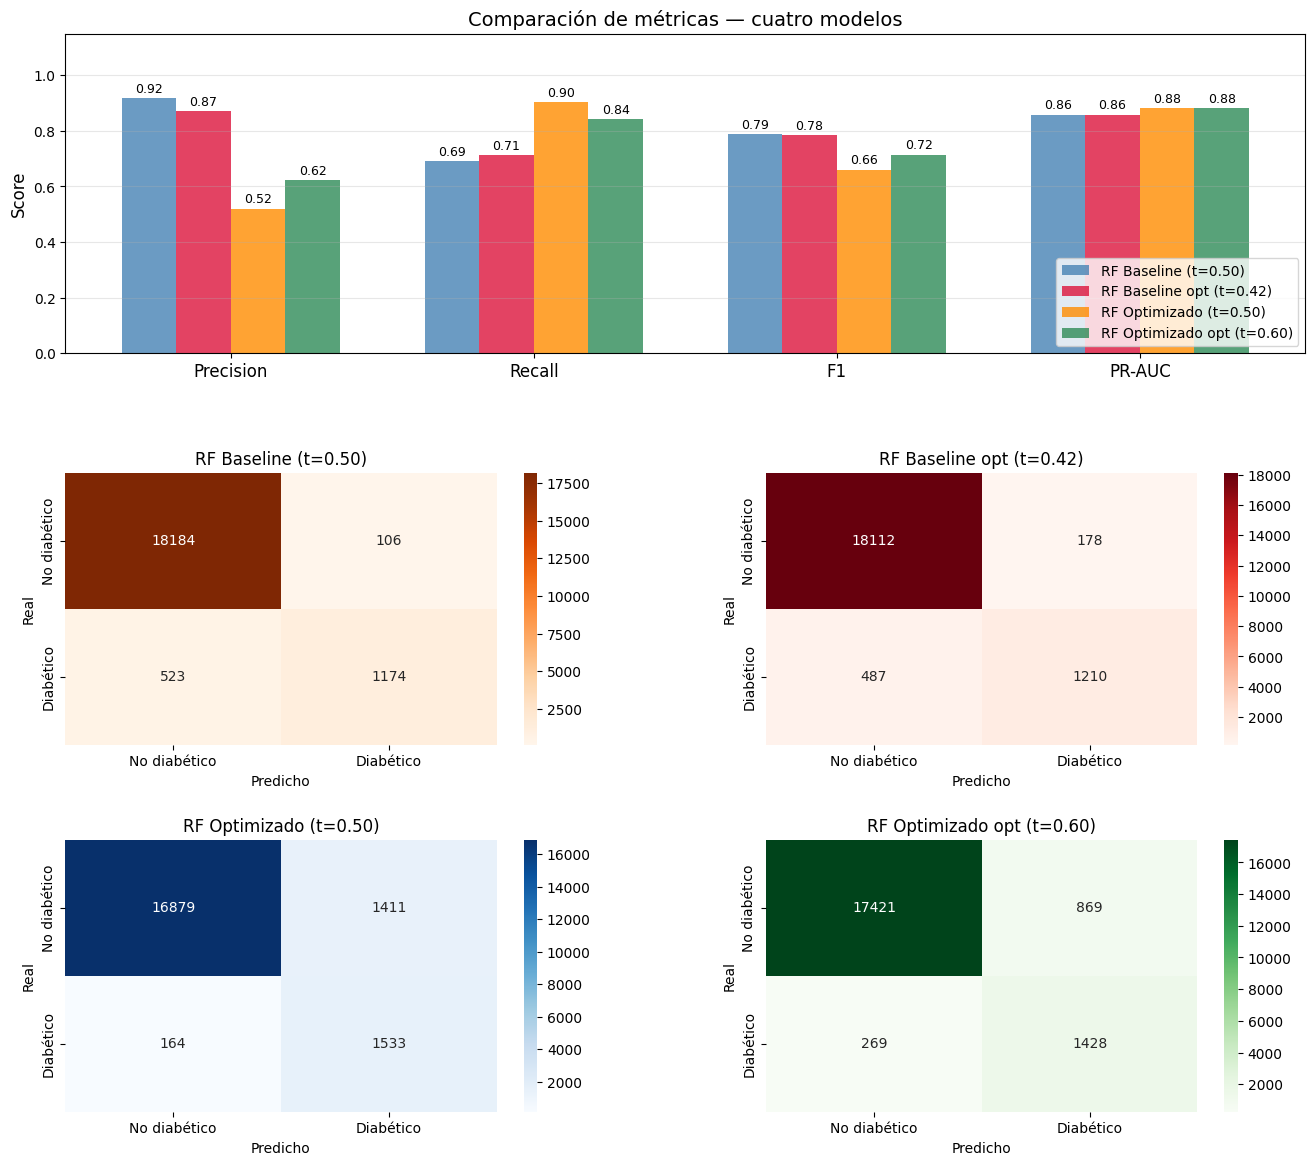

Guardado: artifacts_rf/rf_comparison.png


In [43]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import precision_score, recall_score, f1_score, average_precision_score, confusion_matrix

# PREDICCIONES
y_pred_base     = (y_prob_test_base >= 0.5).astype(int)
y_pred_base_opt = (y_prob_test_base >= best_threshold_base).astype(int)
y_pred_opt_05   = (y_prob_test >= 0.5).astype(int)
y_pred_opt      = (y_prob_test >= best_threshold).astype(int)

# MÉTRICAS
def get_metrics(y_true, y_pred, y_score):
    return {
        "Precision": precision_score(y_true, y_pred),
        "Recall":    recall_score(y_true, y_pred),
        "F1":        f1_score(y_true, y_pred),
        "PR-AUC":    average_precision_score(y_true, y_score),
    }

base_metrics     = get_metrics(y_test, y_pred_base,     y_prob_test_base)
base_opt_metrics = get_metrics(y_test, y_pred_base_opt, y_prob_test_base)
opt05_metrics    = get_metrics(y_test, y_pred_opt_05,   y_prob_test)
opt_metrics      = get_metrics(y_test, y_pred_opt,      y_prob_test)

# MATRICES DE CONFUSIÓN
cm_base     = confusion_matrix(y_test, y_pred_base)
cm_base_opt = confusion_matrix(y_test, y_pred_base_opt)
cm_opt_05   = confusion_matrix(y_test, y_pred_opt_05)
cm_opt      = confusion_matrix(y_test, y_pred_opt)

# FIGURA
fig = plt.figure(figsize=(16, 14))
gs = gridspec.GridSpec(2, 1, height_ratios=[1, 2], hspace=0.25)

ax_bar = fig.add_subplot(gs[0])
metrics_names = ['Precision', 'Recall', 'F1', 'PR-AUC']
x = np.arange(len(metrics_names))
w = 0.18

base_vals     = [base_metrics[m]     for m in metrics_names]
base_opt_vals = [base_opt_metrics[m] for m in metrics_names]
opt05_vals    = [opt05_metrics[m]    for m in metrics_names]
opt_vals      = [opt_metrics[m]      for m in metrics_names]

ax_bar.bar(x - 1.5*w, base_vals,     w, label='RF Baseline (t=0.50)',                           color='steelblue',  alpha=0.8)
ax_bar.bar(x - 0.5*w, base_opt_vals, w, label=f'RF Baseline opt (t={best_threshold_base:.2f})', color='crimson',    alpha=0.8)
ax_bar.bar(x + 0.5*w, opt05_vals,    w, label='RF Optimizado (t=0.50)',                         color='darkorange', alpha=0.8)
ax_bar.bar(x + 1.5*w, opt_vals,      w, label=f'RF Optimizado opt (t={best_threshold:.2f})',    color='seagreen',   alpha=0.8)

ax_bar.set_xticks(x)
ax_bar.set_xticklabels(metrics_names, fontsize=12)
ax_bar.set_ylim([0, 1.15])
ax_bar.set_ylabel('Score', fontsize=12)
ax_bar.set_title('Comparación de métricas — cuatro modelos', fontsize=14)
ax_bar.legend(fontsize=10, loc='lower right')
ax_bar.grid(axis='y', alpha=0.3)
for bars in ax_bar.containers:
    ax_bar.bar_label(bars, fmt='%.2f', padding=2, fontsize=9)

gs_bottom = gridspec.GridSpecFromSubplotSpec(2, 2, subplot_spec=gs[1], hspace=0.35, wspace=0.3)
labels = ['No diabético', 'Diabético']

ax_cm1 = fig.add_subplot(gs_bottom[0, 0])
sns.heatmap(cm_base, annot=True, fmt='d', cmap='Oranges', ax=ax_cm1, xticklabels=labels, yticklabels=labels)
ax_cm1.set_title('RF Baseline (t=0.50)', fontsize=12)
ax_cm1.set_xlabel('Predicho'); ax_cm1.set_ylabel('Real')

ax_cm2 = fig.add_subplot(gs_bottom[0, 1])
sns.heatmap(cm_base_opt, annot=True, fmt='d', cmap='Reds', ax=ax_cm2, xticklabels=labels, yticklabels=labels)
ax_cm2.set_title(f'RF Baseline opt (t={best_threshold_base:.2f})', fontsize=12)
ax_cm2.set_xlabel('Predicho'); ax_cm2.set_ylabel('Real')

ax_cm3 = fig.add_subplot(gs_bottom[1, 0])
sns.heatmap(cm_opt_05, annot=True, fmt='d', cmap='Blues', ax=ax_cm3, xticklabels=labels, yticklabels=labels)
ax_cm3.set_title('RF Optimizado (t=0.50)', fontsize=12)
ax_cm3.set_xlabel('Predicho'); ax_cm3.set_ylabel('Real')

ax_cm4 = fig.add_subplot(gs_bottom[1, 1])
sns.heatmap(cm_opt, annot=True, fmt='d', cmap='Greens', ax=ax_cm4, xticklabels=labels, yticklabels=labels)
ax_cm4.set_title(f'RF Optimizado opt (t={best_threshold:.2f})', fontsize=12)
ax_cm4.set_xlabel('Predicho'); ax_cm4.set_ylabel('Real')

plt.savefig('artifacts_rf/rf_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: artifacts_rf/rf_comparison.png')


- Baselines: Alrededor de 500 personas con diabetes a las que el modelo les dijo que no tienen diabetes se fueron a casa sin tratamiento. Está sesgado hacia la clase mayoritaria (los no diabéticos), logrando una precisión alta a costa de dejar desprotegidos a los enfermos reales.
- Optimizados: Falsos negativos se desploman, en particular en el RF sin el umbral optimizado, se pasan a solo tener 164. El Recall sube drásticamente. Contrapartida: Los Falsos Positivos saltaron a 1,411, la Precisión cae.

# 15. Random Forest sin variables altamente explicativas

El objetivo de este apartado es evaluar la capacidad predictiva del Random Forest **sin las dos variables más informativas del dataset**: `HbA1c_level` y `blood_glucose_level`. Ambas son resultados de pruebas diagnósticas que, en muchos contextos clínicos, pueden no estar disponibles en el momento de la primera valoración de un paciente.

La pregunta que se pretende responder es: ¿qué tan bien puede el modelo predecir diabetes usando únicamente variables de estilo de vida y factores de riesgo clásicos (edad, IMC, hipertensión, tabaquismo, etc.)? Si el modelo mantiene un rendimiento aceptable sin estas variables, sería útil para un cribado previo a la analítica, por ejemplo en encuestas de salud o consultas de atención primaria sin acceso inmediato al laboratorio.

Se aplica la misma metodología que en el apartado 9 (RandomizedSearchCV con StratifiedKFold y PR-AUC como métrica de optimización) para garantizar que la comparación entre ambos modelos sea directa.

Se definen los hiperparámetros:

Se reutiliza el mismo espacio de búsqueda `rf_params` definido en  el apartado 9 para facilitar la comparación directa entre los dos modelos.

Se aplica el pipeline:

Los hiperparámetros explorados por el RandomizedSearchCV y su significado son:

- **n_estimators** [100, 200, 300, 500]: número de árboles del bosque. Más árboles reducen la varianza del modelo (efecto del promediado) a costa de mayor tiempo de cómputo.
- **max_depth** [5, 10, 15, 20, None]: profundidad máxima de cada árbol. Limitar la profundidad impide que los árboles memoricen el conjunto de entrenamiento; `None` significa sin restricción.
- **max_features** ['sqrt', 'log2']: número de features evaluadas en cada split. Reducir este número aumenta la diversidad entre árboles y reduce la correlación del ensemble.
- **min_samples_split** [2, 10, 15, 20]: número mínimo de muestras necesarias para dividir un nodo. Valores altos evitan divisiones sobre grupos con escasa información estadística, reduciendo el sobreajuste.
- **min_samples_leaf** [5, 10, 15, 20]: número mínimo de muestras que debe contener una hoja. Impide hojas muy pequeñas que memoricen casos concretos; es el principal mecanismo de regularización a nivel de nodo.
- **max_samples** [None, 0.7, 0.8]: fracción del conjunto de entrenamiento usada para entrenar cada árbol (bagging). `None` equivale al 100%; valores menores aumentan la diversidad del ensemble.
- **ccp_alpha** [0.0, 0.001, 0.01]: parámetro de poda de coste-complejidad post-entrenamiento. Valores mayores podan más ramas, simplificando el modelo.

In [44]:
X_train_red = X_train.drop(columns=['HbA1c_level', 'blood_glucose_level'])
X_test_red  = X_test.drop(columns=['HbA1c_level', 'blood_glucose_level'])

preprocessor_red = ColumnTransformer([
    ('categorical', OneHotEncoder(handle_unknown='ignore'), ['gender', 'smoking_history']),
], remainder='passthrough', verbose_feature_names_out=False)

rf_pipeline_red = Pipeline([
    ('smoking_merger', SmokingMerger()),
    ('preprocessor', preprocessor_red),
    ('model', RandomForestClassifier(
        bootstrap=True,
        n_jobs=-1,
        random_state=42,
        class_weight='balanced',
        criterion='gini'
    ))
])

Se configura el RandomizedSearchCV:

In [45]:
cv_red = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_search_red = RandomizedSearchCV(
    rf_pipeline_red,
    param_distributions=rf_params,
    n_iter=30,
    scoring='average_precision',
    cv=cv_red,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

Entrenamiento:

In [46]:
rf_search_red.fit(X_train_red, y_train)
print('Mejores parámetros:', rf_search_red.best_params_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


c:\Users\dmoya\grupo_1\.venv\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Mejores parámetros: {'model__n_estimators': 300, 'model__min_samples_split': 2, 'model__min_samples_leaf': 10, 'model__max_samples': 0.7, 'model__max_features': 'sqrt', 'model__max_depth': 10, 'model__ccp_alpha': 0.0}


Resultados por fold. Muestra las 3 mejores combinaciones de hiperparámetros ordenadas por PR-AUC medio descendente:

In [47]:
results_red = pd.DataFrame(rf_search_red.cv_results_)
results_red[[
    'param_model__n_estimators',
    'param_model__max_depth',
    'param_model__max_features',
    'param_model__min_samples_split',
    'param_model__min_samples_leaf',
    'param_model__max_samples',
    'param_model__ccp_alpha',
    'mean_test_score',
    'std_test_score',
    'rank_test_score'
]].sort_values('mean_test_score', ascending=False).head(3)

,param_model__n_estimators,param_model__max_depth,param_model__max_features,param_model__min_samples_split,param_model__min_samples_leaf,param_model__max_samples,param_model__ccp_alpha,mean_test_score,std_test_score,rank_test_score
7,300,10,sqrt,2,10,0.7,0.0,0.316205,0.011163,1
28,300,10,sqrt,15,10,0.7,0.0,0.316205,0.011163,1
29,300,15,log2,15,20,0.7,0.0,0.314262,0.011248,3


### Evaluación final train/test

=== TRAIN ===
Recall:    0.8010
Precision: 0.2260
PR-AUC:    0.3855

=== TEST ===
Recall:    0.7761
Precision: 0.2197
PR-AUC:    0.3140


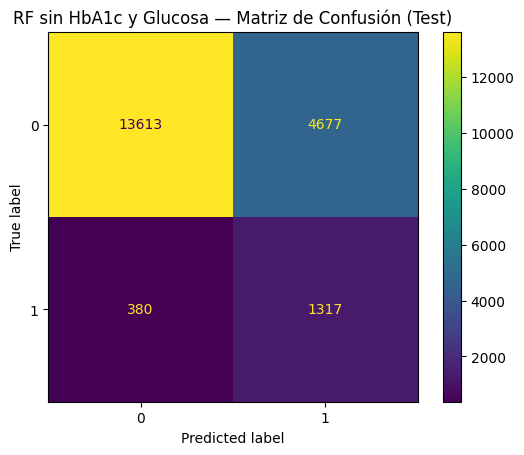

In [48]:
y_pred_train_red = rf_search_red.predict(X_train_red)
y_prob_train_red = rf_search_red.predict_proba(X_train_red)[:, 1]

y_pred_test_red = rf_search_red.predict(X_test_red)
y_prob_test_red = rf_search_red.predict_proba(X_test_red)[:, 1]

print("=== TRAIN ===")
print(f"Recall:    {recall_score(y_train, y_pred_train_red):.4f}")
print(f"Precision: {precision_score(y_train, y_pred_train_red):.4f}")
print(f"PR-AUC:    {average_precision_score(y_train, y_prob_train_red):.4f}")

print("\n=== TEST ===")
print(f"Recall:    {recall_score(y_test, y_pred_test_red):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_test_red):.4f}")
print(f"PR-AUC:    {average_precision_score(y_test, y_prob_test_red):.4f}")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test_red)
plt.title('RF sin HbA1c y Glucosa — Matriz de Confusión (Test)')
plt.show()

## Feature Importance - Shap Values

In [49]:
best_pipeline_red = rf_search_red.best_estimator_
smoking_merger_red_fit = best_pipeline_red.named_steps['smoking_merger']
preprocessor_red_fit   = best_pipeline_red.named_steps['preprocessor']
best_rf_red            = best_pipeline_red.named_steps['model']

Xp_train_red = preprocessor_red_fit.transform(smoking_merger_red_fit.transform(X_train_red))
fnames_red   = list(preprocessor_red_fit.get_feature_names_out())

X_shap_red = Xp_train_red[:500]

explainer_red = shap.TreeExplainer(best_rf_red)
sv_red = explainer_red.shap_values(X_shap_red)
if isinstance(sv_red, list):
    shap_class1_red = sv_red[1]
else:
    shap_class1_red = sv_red[:, :, 1]

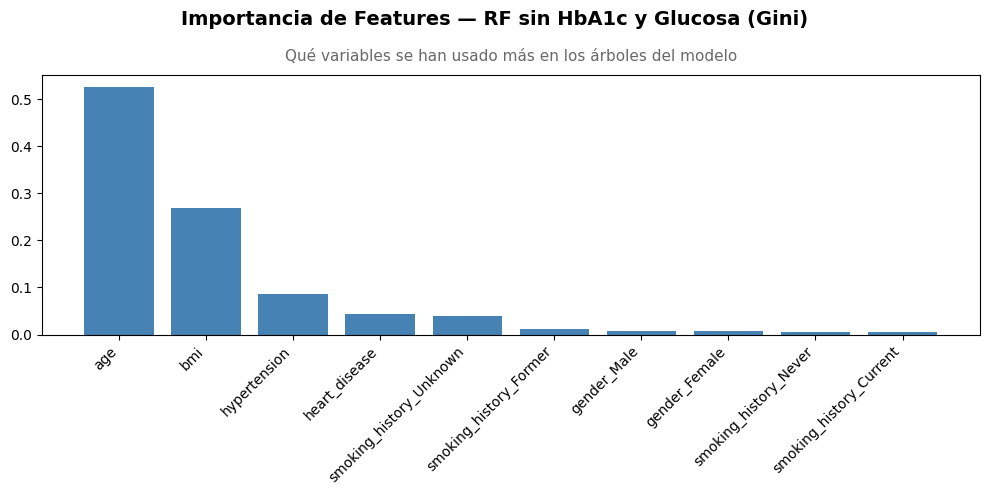

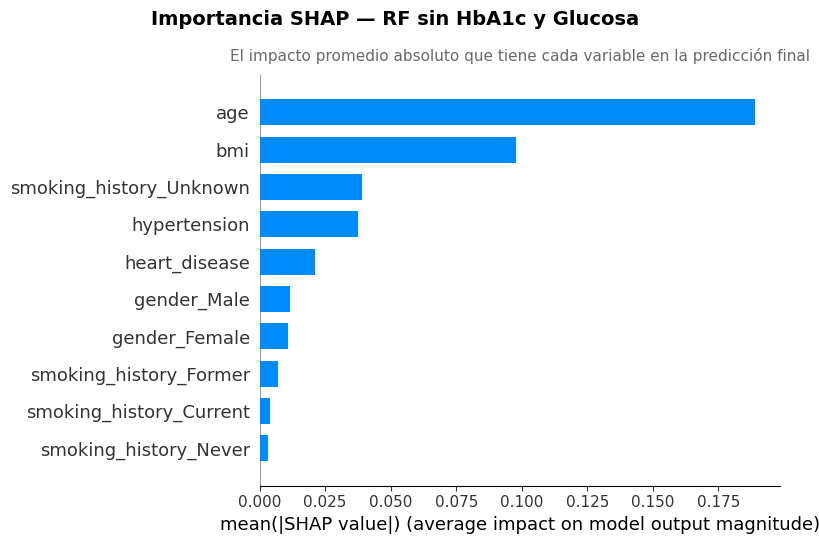

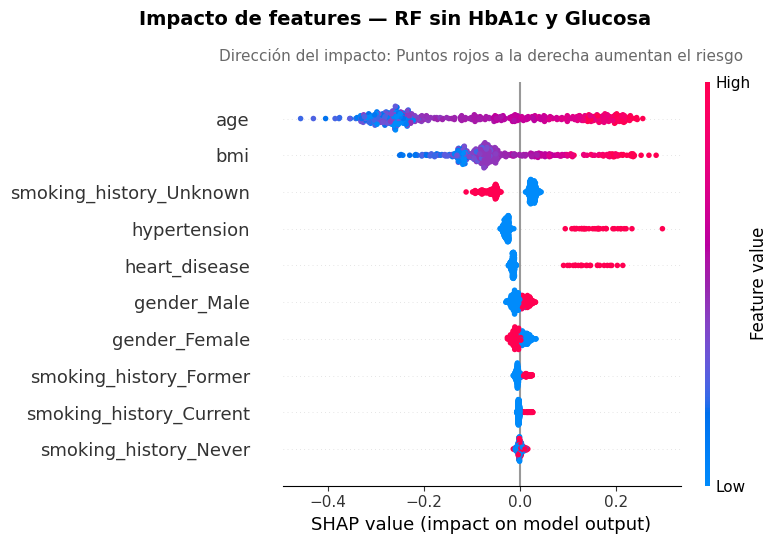

In [50]:
# --- Feature Importance nativa (Gini) ---
importances_red = best_rf_red.feature_importances_
indices_red = np.argsort(importances_red)[::-1]
plt.figure(figsize=(10, 5))
plt.bar(range(len(fnames_red)), importances_red[indices_red], color='steelblue')
plt.xticks(range(len(fnames_red)), [fnames_red[i] for i in indices_red], rotation=45, ha='right')
plt.suptitle('Importancia de Features — RF sin HbA1c y Glucosa (Gini)', fontsize=14, fontweight='bold')
plt.title('Qué variables se han usado más en los árboles del modelo', fontsize=11, color='dimgrey', pad=10)
plt.tight_layout()
plt.show()

# --- SHAP Gráfico de Barras ---
shap.summary_plot(shap_class1_red, X_shap_red, feature_names=fnames_red, plot_type='bar', show=False)
plt.suptitle('Importancia SHAP — RF sin HbA1c y Glucosa', fontsize=14, fontweight='bold')
plt.title('El impacto promedio absoluto que tiene cada variable en la predicción final', fontsize=11, color='dimgrey', pad=10)
plt.tight_layout()
plt.show()

# --- SHAP Gráfico de Puntos (Beeswarm) ---
shap.summary_plot(shap_class1_red, X_shap_red, feature_names=fnames_red, show=False)
plt.suptitle('Impacto de features — RF sin HbA1c y Glucosa', fontsize=14, fontweight='bold')
plt.title('Dirección del impacto: Puntos rojos a la derecha aumentan el riesgo', fontsize=11, color='dimgrey', pad=15)
plt.tight_layout()
plt.show()